In [17]:
import pandas as pd 

In [18]:
# Load data
df = pd.read_csv('/Users/mraffyzeidan/Learning/xcap/Client-BPRSK/BPRSK/Main/BankLongLat.csv')
print(f"Total data: {len(df)} bank")

Total data: 2055 bank


In [26]:
# Load GeoJSON Indonesia 
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt

print("📥 Loading Indonesia GeoJSON...")

# URL GeoJSON Indonesia dari GitHub
url = "https://raw.githubusercontent.com/ans-4175/peta-indonesia-geojson/master/indonesia-prov.geojson"

try:
    print("   Downloading dari GitHub...")
    indonesia = gpd.read_file(url)
    
    print(f"✅ GeoJSON Indonesia berhasil diload!")
    print(f"   Jumlah provinsi: {len(indonesia)}")
    print(f"   CRS: {indonesia.crs}")
    print(f"   Bounds: {indonesia.total_bounds}")
    print(f"   Columns: {list(indonesia.columns)}")
    
    # Dissolve all provinces into one Indonesia polygon
    indonesia_merged = indonesia.dissolve()
    
    # Plot preview GeoJSON
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
    
    # Plot per provinsi
    indonesia.plot(ax=ax1, color='lightblue', edgecolor='black', linewidth=0.5, alpha=0.7)
    ax1.set_title('Peta Indonesia Per Provinsi', fontsize=12, fontweight='bold')
    ax1.set_xlabel('Longitude')
    ax1.set_ylabel('Latitude')
    ax1.grid(True, alpha=0.3)
    
    # Plot merged
    indonesia_merged.plot(ax=ax2, color='#B2DFDB', edgecolor='#004D40', linewidth=1.5, alpha=0.7)
    ax2.set_title('Peta Indonesia (Merged)', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Longitude')
    ax2.set_ylabel('Latitude')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Use merged version for validation
    indonesia = indonesia_merged
    
except Exception as e:
    print(f"❌ Error: {e}")
    print("\nTrying alternative source...")
    try:
        # Alternative: world countries
        url2 = "https://raw.githubusercontent.com/johan/world.geo.json/master/countries/IDN.geo.json"
        indonesia = gpd.read_file(url2)
        print(f"✅ Loaded from alternative source!")
    except:
        print("❌ Failed to load GeoJSON")

📥 Loading Indonesia GeoJSON...
✅ GeoJSON Indonesia berhasil diload!
   Jumlah provinsi: 34
   CRS: EPSG:4326
   Bounds: [ 95.195138 -10.91942  141.011765   5.877151]
   Columns: ['ID', 'kode', 'Propinsi', 'SUMBER', 'geometry']
❌ Error: TopologyException: side location conflict at 102.7543740403605 0.9123262289185794. This can occur if the input geometry is invalid.

Trying alternative source...
✅ Loaded from alternative source!


In [27]:
# Check setiap koordinat bank apakah berada di dalam polygon Indonesia
from shapely.geometry import Point
import numpy as np

print("🔍 Checking koordinat bank dengan GeoJSON Indonesia...")
print("="*80)

# Buat GeoDataFrame dari koordinat bank
geometry = [Point(xy) for xy in zip(df['Longitude'], df['Latitude'])]
gdf_banks = gpd.GeoDataFrame(df, geometry=geometry, crs='EPSG:4326')

# Ensure CRS match
if indonesia.crs != gdf_banks.crs:
    indonesia = indonesia.to_crs(gdf_banks.crs)

# Spatial join untuk cek point in polygon
banks_in_indonesia = gpd.sjoin(gdf_banks, indonesia, how='left', predicate='within')

# Koordinat yang TIDAK berada di dalam Indonesia
df['in_indonesia'] = banks_in_indonesia['index_right'].notna()
df_outside_indonesia = df[~df['in_indonesia']].copy()

print(f"\n📊 HASIL VALIDASI DENGAN GEOJSON:")
print(f"✅ Koordinat DI DALAM Indonesia: {df['in_indonesia'].sum()} bank ({df['in_indonesia'].sum()/len(df)*100:.2f}%)")
print(f"❌ Koordinat DI LUAR Indonesia: {len(df_outside_indonesia)} bank ({len(df_outside_indonesia)/len(df)*100:.2f}%)")

if len(df_outside_indonesia) > 0:
    print(f"\n🚨 BANK DENGAN KOORDINAT DI LUAR INDONESIA:")
    print("="*100)
    for idx, row in df_outside_indonesia.iterrows():
        print(f"\n📍 {row['Nama Bank']}")
        print(f"   Provinsi: {row['Provinsi']}")
        print(f"   Kabupaten: {row['Kabupaten/Kota']}")
        print(f"   Koordinat: ({row['Latitude']:.6f}, {row['Longitude']:.6f})")
        print(f"   Google Maps: https://www.google.com/maps?q={row['Latitude']},{row['Longitude']}")
        print(f"   Jenis: {row['Jenis']}")
else:
    print("\n🎉 SEMUA KOORDINAT VALID! Berada di dalam wilayah Indonesia!")

🔍 Checking koordinat bank dengan GeoJSON Indonesia...

📊 HASIL VALIDASI DENGAN GEOJSON:
✅ Koordinat DI DALAM Indonesia: 1766 bank (85.94%)
❌ Koordinat DI LUAR Indonesia: 289 bank (14.06%)

🚨 BANK DENGAN KOORDINAT DI LUAR INDONESIA:

📍 PD BPR Indramayu
   Provinsi: Provinsi Jawa Barat
   Kabupaten: Kab. Bekasi
   Koordinat: (-6.363361, 108.287432)
   Google Maps: https://www.google.com/maps?q=-6.3633607,108.2874323
   Jenis: Konvensional

📍 PT BD. BALI RESPATI
   Provinsi: Provinsi Jawa Barat
   Kabupaten: Kab. Bekasi
   Koordinat: (-7.408884, 106.039043)
   Google Maps: https://www.google.com/maps?q=-7.4088844,106.0390434
   Jenis: Konvensional

📍 PT BPR Artha Galuh Mandiri Jawa Barat Perseroda
   Provinsi: Provinsi Jawa Barat
   Kabupaten: Kab. Ciamis
   Koordinat: (-7.808728, 108.436118)
   Google Maps: https://www.google.com/maps?q=-7.8087283,108.4361184
   Jenis: Konvensional

📍 PD. BPR LPK Cantigi Kulon
   Provinsi: Provinsi Jawa Barat
   Kabupaten: Kab. Indramayu
   Koordinat: (-

/var/folders/m3/3gmfjhln13qbt6p_47473gs40000gn/T/ipykernel_79781/4250330926.py:61: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/var/folders/m3/3gmfjhln13qbt6p_47473gs40000gn/T/ipykernel_79781/4250330926.py:61: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/var/folders/m3/3gmfjhln13qbt6p_47473gs40000gn/T/ipykernel_79781/4250330926.py:61: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/Users/mraffyzeidan/anaconda3/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/mraffyzeidan/anaconda3/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(

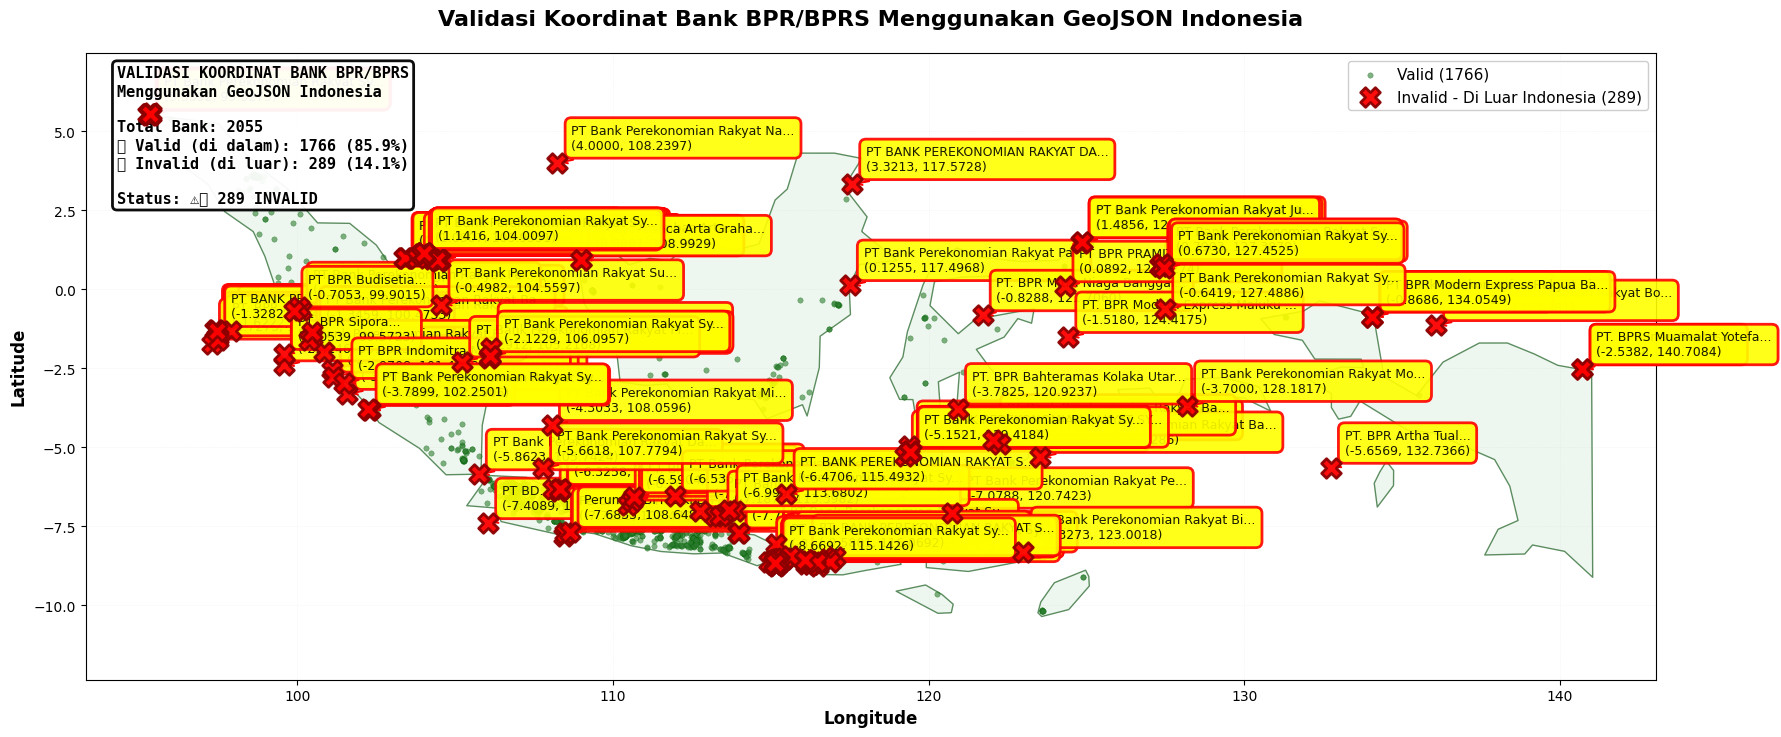


💾 File koordinat invalid disimpan ke: /Users/mraffyzeidan/Learning/xcap/Client-BPRSK/BankLongLat_INVALID.csv


In [28]:
# Plot final: Overlay koordinat bank di atas peta Indonesia GeoJSON
fig, ax = plt.subplots(figsize=(18, 12))

# Plot peta Indonesia
indonesia.plot(ax=ax, color='#E8F5E9', edgecolor='#1B5E20', linewidth=1, alpha=0.7)

# Plot koordinat yang VALID (di dalam Indonesia)
if df['in_indonesia'].sum() > 0:
    df_valid = df[df['in_indonesia']]
    ax.scatter(df_valid['Longitude'], df_valid['Latitude'], 
              c='#2E7D32', s=15, alpha=0.6, edgecolors='darkgreen', 
              linewidth=0.3, label=f'Valid ({len(df_valid)})', marker='o', zorder=3)

# Plot koordinat yang INVALID (di luar Indonesia)
if len(df_outside_indonesia) > 0:
    ax.scatter(df_outside_indonesia['Longitude'], df_outside_indonesia['Latitude'], 
              c='red', s=200, alpha=0.95, edgecolors='darkred', 
              linewidth=2, label=f'Invalid - Di Luar Indonesia ({len(df_outside_indonesia)})', 
              marker='X', zorder=5)
    
    # Label untuk koordinat invalid
    for idx, row in df_outside_indonesia.iterrows():
        ax.annotate(f"{row['Nama Bank'][:30]}...\n({row['Latitude']:.4f}, {row['Longitude']:.4f})", 
                   (row['Longitude'], row['Latitude']),
                   xytext=(10, 10), textcoords='offset points',
                   fontsize=9, alpha=0.9, 
                   bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', 
                            edgecolor='red', linewidth=2, alpha=0.9),
                   arrowprops=dict(arrowstyle='->', color='red', lw=1.5))

# Info box
status_text = "✅ SEMUA VALID" if len(df_outside_indonesia) == 0 else f"⚠️ {len(df_outside_indonesia)} INVALID"
info_text = f"""VALIDASI KOORDINAT BANK BPR/BPRS
Menggunakan GeoJSON Indonesia

Total Bank: {len(df)}
✅ Valid (di dalam): {df['in_indonesia'].sum()} ({df['in_indonesia'].sum()/len(df)*100:.1f}%)
❌ Invalid (di luar): {len(df_outside_indonesia)} ({len(df_outside_indonesia)/len(df)*100:.1f}%)

Status: {status_text}"""

ax.text(0.02, 0.98, info_text, 
        transform=ax.transAxes, fontsize=11, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', 
                 edgecolor='black', linewidth=2, alpha=0.95),
        family='monospace', fontweight='bold')

ax.set_xlabel('Longitude', fontsize=12, fontweight='bold')
ax.set_ylabel('Latitude', fontsize=12, fontweight='bold')
ax.set_title('Validasi Koordinat Bank BPR/BPRS Menggunakan GeoJSON Indonesia', 
            fontsize=16, fontweight='bold', pad=20)
ax.legend(fontsize=11, loc='upper right', framealpha=0.95)
ax.grid(True, alpha=0.2, linestyle=':', linewidth=0.5)

# Set bounds sedikit lebih lebar
bounds = indonesia.total_bounds
margin = 2
ax.set_xlim(bounds[0] - margin, bounds[2] + margin)
ax.set_ylim(bounds[1] - margin, bounds[3] + margin)

plt.tight_layout()
plt.show()

# Export hasil jika ada yang invalid
if len(df_outside_indonesia) > 0:
    output_file = '/Users/mraffyzeidan/Learning/xcap/Client-BPRSK/BankLongLat_INVALID.csv'
    df_outside_indonesia.to_csv(output_file, index=False)
    print(f"\n💾 File koordinat invalid disimpan ke: {output_file}")

In [29]:
# Plot interaktif dengan Plotly
import plotly.graph_objects as go
import json

print("🎨 Membuat visualisasi interaktif dengan Plotly...")

# Buat figure
fig = go.Figure()

# 1. Plot polygon Indonesia dari GeoJSON
# Convert GeoJSON to format yang bisa diplot Plotly
for idx, row in indonesia.iterrows():
    geom = row.geometry
    
    if geom.geom_type == 'Polygon':
        coords = list(geom.exterior.coords)
        lons = [c[0] for c in coords]
        lats = [c[1] for c in coords]
        
        fig.add_trace(go.Scattergeo(
            lon=lons,
            lat=lats,
            mode='lines',
            line=dict(width=1.5, color='#004D40'),
            fill='toself',
            fillcolor='rgba(184, 233, 229, 0.3)',
            showlegend=False,
            hoverinfo='skip'
        ))
    elif geom.geom_type == 'MultiPolygon':
        for poly in geom.geoms:
            coords = list(poly.exterior.coords)
            lons = [c[0] for c in coords]
            lats = [c[1] for c in coords]
            
            fig.add_trace(go.Scattergeo(
                lon=lons,
                lat=lats,
                mode='lines',
                line=dict(width=1.5, color='#004D40'),
                fill='toself',
                fillcolor='rgba(184, 233, 229, 0.3)',
                showlegend=False,
                hoverinfo='skip'
            ))

# 2. Plot koordinat VALID (di dalam Indonesia)
if df['in_indonesia'].sum() > 0:
    df_valid = df[df['in_indonesia']]
    
    fig.add_trace(go.Scattergeo(
        lon=df_valid['Longitude'],
        lat=df_valid['Latitude'],
        mode='markers',
        marker=dict(
            size=6,
            color='#2E7D32',
            line=dict(width=0.5, color='darkgreen'),
            opacity=0.7
        ),
        name=f'✅ Valid ({len(df_valid)})',
        text=df_valid.apply(lambda x: f"{x['Nama Bank']}<br>{x['Provinsi']}<br>{x['Kabupaten/Kota']}", axis=1),
        hovertemplate='<b>%{text}</b><br>Lat: %{lat:.4f}<br>Lon: %{lon:.4f}<extra></extra>'
    ))

# 3. Plot koordinat INVALID (di luar Indonesia)  
if len(df_outside_indonesia) > 0:
    fig.add_trace(go.Scattergeo(
        lon=df_outside_indonesia['Longitude'],
        lat=df_outside_indonesia['Latitude'],
        mode='markers',
        marker=dict(
            size=15,
            color='red',
            symbol='x',
            line=dict(width=2, color='darkred'),
            opacity=0.95
        ),
        name=f'❌ Invalid ({len(df_outside_indonesia)})',
        text=df_outside_indonesia.apply(
            lambda x: f"<b>{x['Nama Bank']}</b><br>Provinsi: {x['Provinsi']}<br>Kab/Kota: {x['Kabupaten/Kota']}<br>Jenis: {x['Jenis']}", 
            axis=1
        ),
        hovertemplate='<b style="color:red">⚠️ KOORDINAT INVALID</b><br>%{text}<br>Lat: %{lat:.6f}<br>Lon: %{lon:.6f}<br>🔗 <a href="https://www.google.com/maps?q=%{lat},%{lon}" target="_blank">Buka di Google Maps</a><extra></extra>'
    ))

# Update layout
bounds = indonesia.total_bounds
center_lon = (bounds[0] + bounds[2]) / 2
center_lat = (bounds[1] + bounds[3]) / 2

fig.update_geos(
    projection_type="mercator",
    visible=True,
    resolution=50,
    showcountries=True,
    countrycolor="lightgray",
    showland=True,
    landcolor="rgb(243, 243, 243)",
    showocean=True,
    oceancolor="rgb(230, 245, 255)",
    center=dict(lon=center_lon, lat=center_lat),
    lonaxis=dict(range=[bounds[0]-2, bounds[2]+2]),
    lataxis=dict(range=[bounds[1]-1, bounds[3]+1]),
)

fig.update_layout(
    title={
        'text': f'<b>Validasi Koordinat Bank BPR/BPRS di Indonesia</b><br><sub>Total: {len(df)} | Valid: {df["in_indonesia"].sum()} ({df["in_indonesia"].sum()/len(df)*100:.1f}%) | Invalid: {len(df_outside_indonesia)} ({len(df_outside_indonesia)/len(df)*100:.1f}%)</sub>',
        'x': 0.5,
        'xanchor': 'center',
        'font': {'size': 18}
    },
    width=1400,
    height=800,
    hovermode='closest',
    showlegend=True,
    legend=dict(
        yanchor="top",
        y=0.99,
        xanchor="right",
        x=0.99,
        bgcolor="rgba(255,255,255,0.9)",
        bordercolor="black",
        borderwidth=1
    )
)

fig.show()

print("\n✨ Plot interaktif siap! Anda bisa:")
print("   - Zoom in/out dengan scroll")
print("   - Pan dengan drag")
print("   - Hover untuk detail bank")
print("   - Klik legend untuk hide/show data")

🎨 Membuat visualisasi interaktif dengan Plotly...



✨ Plot interaktif siap! Anda bisa:
   - Zoom in/out dengan scroll
   - Pan dengan drag
   - Hover untuk detail bank
   - Klik legend untuk hide/show data


In [31]:
# Cek sample koordinat "invalid" dengan Google Maps link
print("🔍 Sample koordinat yang dianggap INVALID (tapi mungkin sebenarnya valid):\n")
print("="*100)

sample_invalid = df_outside_indonesia.head(10)
for idx, row in sample_invalid.iterrows():
    print(f"\n{row['Nama Bank']}")
    print(f"  📍 {row['Provinsi']} - {row['Kabupaten/Kota']}")
    print(f"  🌐 Koordinat: {row['Latitude']:.6f}, {row['Longitude']:.6f}")
    print(f"  🔗 Cek di Google Maps: https://www.google.com/maps?q={row['Latitude']},{row['Longitude']}")

print(f"\n\n⚠️ CATATAN: GeoJSON yang dipakai mungkin resolusinya rendah atau tidak mencakup:")
print("   - Pulau-pulau kecil (Bangka, Belitung, Lombok, pulau-pulau kecil lainnya)")
print("   - Detail coastline yang akurat")
print("   - Wilayah kepulauan terluar")
print("\n💡 Solusi: Perlu GeoJSON Indonesia dengan resolusi lebih tinggi atau buffer zone")

🔍 Sample koordinat yang dianggap INVALID (tapi mungkin sebenarnya valid):


PD BPR Indramayu
  📍 Provinsi Jawa Barat - Kab. Bekasi
  🌐 Koordinat: -6.363361, 108.287432
  🔗 Cek di Google Maps: https://www.google.com/maps?q=-6.3633607,108.2874323

PT BD. BALI RESPATI
  📍 Provinsi Jawa Barat - Kab. Bekasi
  🌐 Koordinat: -7.408884, 106.039043
  🔗 Cek di Google Maps: https://www.google.com/maps?q=-7.4088844,106.0390434

PT BPR Artha Galuh Mandiri Jawa Barat Perseroda
  📍 Provinsi Jawa Barat - Kab. Ciamis
  🌐 Koordinat: -7.808728, 108.436118
  🔗 Cek di Google Maps: https://www.google.com/maps?q=-7.8087283,108.4361184

PD. BPR LPK Cantigi Kulon
  📍 Provinsi Jawa Barat - Kab. Indramayu
  🌐 Koordinat: -6.350108, 108.266994
  🔗 Cek di Google Maps: https://www.google.com/maps?q=-6.3501075,108.2669938

PD. BPR LPK Arahan Kidul
  📍 Provinsi Jawa Barat - Kab. Indramayu
  🌐 Koordinat: -6.366316, 108.280865
  🔗 Cek di Google Maps: https://www.google.com/maps?q=-6.3663156,108.2808648

PT Bank Perekonom

In [33]:
# Solusi: Buat buffer zone di sekitar polygon Indonesia untuk akomodasi pulau kecil
print("🔧 Membuat buffer zone untuk akomodasi pulau-pulau kecil...")

# Buat buffer 0.1 derajat (~11 km) di sekitar polygon Indonesia
indonesia_buffered = indonesia.copy()
indonesia_buffered['geometry'] = indonesia_buffered.geometry.buffer(0.15)  # ~16.5 km buffer

print(f"✅ Buffer zone {0.15} derajat (~16.5 km) berhasil dibuat!")

# Re-validasi dengan buffer zone
geometry = [Point(xy) for xy in zip(df['Longitude'], df['Latitude'])]
gdf_banks = gpd.GeoDataFrame(df, geometry=geometry, crs='EPSG:4326')

banks_in_buffered = gpd.sjoin(gdf_banks, indonesia_buffered, how='left', predicate='within')
df['in_indonesia_buffered'] = banks_in_buffered['index_right'].notna()
df_outside_buffered = df[~df['in_indonesia_buffered']].copy()

print(f"\n📊 HASIL RE-VALIDASI DENGAN BUFFER ZONE:")
print(f"✅ Koordinat DI DALAM (+ buffer): {df['in_indonesia_buffered'].sum()} bank ({df['in_indonesia_buffered'].sum()/len(df)*100:.2f}%)")
print(f"❌ Koordinat DI LUAR (+ buffer): {len(df_outside_buffered)} bank ({len(df_outside_buffered)/len(df)*100:.2f}%)")

print(f"\n📉 Pengurangan false positive:")
print(f"   Sebelum buffer: {len(df_outside_indonesia)} invalid")
print(f"   Setelah buffer: {len(df_outside_buffered)} invalid") 
print(f"   Terkoreksi: {len(df_outside_indonesia) - len(df_outside_buffered)} koordinat ({(len(df_outside_indonesia) - len(df_outside_buffered))/len(df_outside_indonesia)*100:.1f}%)")

if len(df_outside_buffered) > 0:
    print(f"\n🚨 BANK YANG MASIH INVALID SETELAH BUFFER:")
    print("="*100)
    for idx, row in df_outside_buffered.head(15).iterrows():
        print(f"\n📍 {row['Nama Bank'][:50]}")
        print(f"   {row['Provinsi']} - {row['Kabupaten/Kota']}")
        print(f"   Koordinat: ({row['Latitude']:.6f}, {row['Longitude']:.6f})")
        print(f"   🔗 https://www.google.com/maps?q={row['Latitude']},{row['Longitude']}")
else:
    print("\n🎉 SEMUA KOORDINAT VALID setelah buffer zone!")

🔧 Membuat buffer zone untuk akomodasi pulau-pulau kecil...
✅ Buffer zone 0.15 derajat (~16.5 km) berhasil dibuat!

📊 HASIL RE-VALIDASI DENGAN BUFFER ZONE:
✅ Koordinat DI DALAM (+ buffer): 1934 bank (94.11%)
❌ Koordinat DI LUAR (+ buffer): 121 bank (5.89%)

📉 Pengurangan false positive:
   Sebelum buffer: 289 invalid
   Setelah buffer: 121 invalid
   Terkoreksi: 168 koordinat (58.1%)

🚨 BANK YANG MASIH INVALID SETELAH BUFFER:

📍 PT BD. BALI RESPATI
   Provinsi Jawa Barat - Kab. Bekasi
   Koordinat: (-7.408884, 106.039043)
   🔗 https://www.google.com/maps?q=-7.4088844,106.0390434

📍 PT Bank Perekonomian Rakyat Mitra Abadi Sejahtera
   Provinsi Jawa Tengah - Kab. Cilacap
   Koordinat: (-4.303257, 108.059570)
   🔗 https://www.google.com/maps?q=-4.3032575,108.0595701

📍 PT BPR Bakti Artha Sejahtera Sampang
   Provinsi Jawa Timur - Kab. Sampang
   Koordinat: (-7.188407, 113.240646)
   🔗 https://www.google.com/maps?q=-7.1884073,113.2406465

📍 PT Bank Perekonomian Rakyat Pamekasan Purapersada


/var/folders/m3/3gmfjhln13qbt6p_47473gs40000gn/T/ipykernel_79781/1665995281.py:6: UserWarning:

Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.




In [37]:
# Plot Plotly dengan buffer zone
import plotly.graph_objects as go

print("🎨 Membuat visualisasi dengan buffer zone...")

fig = go.Figure()

# 1. Plot polygon Indonesia ASLI
for idx, row in indonesia.iterrows():
    geom = row.geometry
    
    if geom.geom_type == 'Polygon':
        coords = list(geom.exterior.coords)
        lons = [c[0] for c in coords]
        lats = [c[1] for c in coords]
        
        fig.add_trace(go.Scattergeo(
            lon=lons,
            lat=lats,
            mode='lines',
            line=dict(width=2, color='#004D40'),
            fill='toself',
            fillcolor='rgba(46, 125, 50, 0.5)',
            name='Indonesia (GeoJSON)',
            showlegend=True,
            hoverinfo='skip',
            legendgroup='indonesia'
        ))
        # Only show legend once
        fig.data[-1].showlegend = (idx == 0)
        
    elif geom.geom_type == 'MultiPolygon':
        for poly_idx, poly in enumerate(geom.geoms):
            coords = list(poly.exterior.coords)
            lons = [c[0] for c in coords]
            lats = [c[1] for c in coords]
            
            fig.add_trace(go.Scattergeo(
                lon=lons,
                lat=lats,
                mode='lines',
                line=dict(width=2, color='#004D40'),
                fill='toself',
                fillcolor='rgba(46, 125, 50, 0.5)',
                name='Indonesia (GeoJSON)',
                showlegend=(idx == 0 and poly_idx == 0),
                hoverinfo='skip',
                legendgroup='indonesia'
            ))

# 2. Plot buffer zone (semi-transparent)
for idx, row in indonesia_buffered.iterrows():
    geom = row.geometry
    
    if geom.geom_type == 'Polygon':
        coords = list(geom.exterior.coords)
        lons = [c[0] for c in coords]
        lats = [c[1] for c in coords]
        
        fig.add_trace(go.Scattergeo(
            lon=lons,
            lat=lats,
            mode='lines',
            line=dict(width=1, color='orange', dash='dot'),
            fill='toself',
            fillcolor='rgba(255, 152, 0, 0.15)',
            name='Buffer Zone (±16.5km)',
            showlegend=(idx == 0),
            hoverinfo='skip',
            legendgroup='buffer'
        ))
    elif geom.geom_type == 'MultiPolygon':
        for poly_idx, poly in enumerate(geom.geoms):
            coords = list(poly.exterior.coords)
            lons = [c[0] for c in coords]
            lats = [c[1] for c in coords]
            
            fig.add_trace(go.Scattergeo(
                lon=lons,
                lat=lats,
                mode='lines',
                line=dict(width=1, color='orange', dash='dot'),
                fill='toself',
                fillcolor='rgba(255, 152, 0, 0.15)',
                name='Buffer Zone (±16.5km)',
                showlegend=(idx == 0 and poly_idx == 0),
                hoverinfo='skip',
                legendgroup='buffer'
            ))

# 3. Plot koordinat VALID
if df['in_indonesia_buffered'].sum() > 0:
    df_valid_buffered = df[df['in_indonesia_buffered']]
    
    fig.add_trace(go.Scattergeo(
        lon=df_valid_buffered['Longitude'],
        lat=df_valid_buffered['Latitude'],
        mode='markers',
        marker=dict(size=5, color='#2E7D32', line=dict(width=0.3, color='darkgreen'), opacity=0.6),
        name=f'✅ Valid ({len(df_valid_buffered)})',
        text=df_valid_buffered.apply(lambda x: f"{x['Nama Bank']}<br>{x['Provinsi']}<br>{x['Kabupaten/Kota']}", axis=1),
        hovertemplate='<b>%{text}</b><br>Lat: %{lat:.4f}<br>Lon: %{lon:.4f}<extra></extra>'
    ))

# 4. Plot koordinat INVALID (setelah buffer)
if len(df_outside_buffered) > 0:
    fig.add_trace(go.Scattergeo(
        lon=df_outside_buffered['Longitude'],
        lat=df_outside_buffered['Latitude'],
        mode='markers',
        marker=dict(size=15, color='red', symbol='x', line=dict(width=2, color='darkred'), opacity=0.95),
        name=f'❌ Invalid ({len(df_outside_buffered)})',
        text=df_outside_buffered.apply(
            lambda x: f"<b>{x['Nama Bank']}</b><br>Provinsi: {x['Provinsi']}<br>Kab/Kota: {x['Kabupaten/Kota']}<br>Jenis: {x['Jenis']}", 
            axis=1
        ),
        hovertemplate='<b style="color:red">⚠️ KOORDINAT INVALID</b><br>%{text}<br>Lat: %{lat:.6f}<br>Lon: %{lon:.6f}<br>🔗 <a href="https://www.google.com/maps?q=%{lat},%{lon}" target="_blank">Google Maps</a><extra></extra>'
    ))

# Update layout
bounds = indonesia.total_bounds
center_lon = (bounds[0] + bounds[2]) / 2
center_lat = (bounds[1] + bounds[3]) / 2

fig.update_geos(
    projection_type="mercator",
    visible=True,
    resolution=50,
    showcountries=True,
    countrycolor="lightgray",
    showland=True,
    landcolor="rgb(243, 243, 243)",
    showocean=True,
    oceancolor="rgb(230, 245, 255)",
    center=dict(lon=center_lon, lat=center_lat),
    lonaxis=dict(range=[bounds[0]-2, bounds[2]+2]),
    lataxis=dict(range=[bounds[1]-1, bounds[3]+1]),
)

fig.update_layout(
    title={
        'text': f'<b>Validasi Koordinat Bank BPR/BPRS (Dengan Buffer Zone)</b><br><sub>Total: {len(df)} | Valid: {df["in_indonesia_buffered"].sum()} ({df["in_indonesia_buffered"].sum()/len(df)*100:.1f}%) | Invalid: {len(df_outside_buffered)} ({len(df_outside_buffered)/len(df)*100:.1f}%)</sub>',
        'x': 0.5,
        'xanchor': 'center',
        'font': {'size': 18}
    },
    width=1400,
    height=800,
    hovermode='closest',
    showlegend=True,
    legend=dict(
        yanchor="top",
        y=0.99,
        xanchor="right",
        x=0.99,
        bgcolor="rgba(255,255,255,0.9)",
        bordercolor="black",
        borderwidth=1
    )
)

fig.show()

print("\n✨ Plot dengan buffer zone siap!")
print("   🟢 Hijau = Polygon Indonesia asli")
print("   🟠 Orange = Buffer zone ±16.5 km")
print("   ✅ Titik hijau = Koordinat valid")
print("   ❌ X merah = Koordinat masih invalid (perlu dicek manual)")

# Export hasil final
if len(df_outside_buffered) > 0:
    output_file = '/Users/mraffyzeidan/Learning/xcap/Client-BPRSK/BankLongLat_INVALID_FINAL.csv'
    df_outside_buffered.to_csv(output_file, index=False)
    print(f"\n💾 File koordinat invalid (final) disimpan ke: {output_file}")

🎨 Membuat visualisasi dengan buffer zone...



✨ Plot dengan buffer zone siap!
   🟢 Hijau = Polygon Indonesia asli
   🟠 Orange = Buffer zone ±16.5 km
   ✅ Titik hijau = Koordinat valid
   ❌ X merah = Koordinat masih invalid (perlu dicek manual)

💾 File koordinat invalid (final) disimpan ke: /Users/mraffyzeidan/Learning/xcap/Client-BPRSK/BankLongLat_INVALID_FINAL.csv


In [38]:
# Plot Plotly - pakai land boundary bawaan Plotly (bukan GeoJSON polygon)
import plotly.graph_objects as go

print("🎨 Membuat visualisasi dengan land boundary Plotly...")

fig = go.Figure()

# Plot koordinat VALID (gunakan buffer zone result)
if df['in_indonesia_buffered'].sum() > 0:
    df_valid_buffered = df[df['in_indonesia_buffered']]
    
    fig.add_trace(go.Scattergeo(
        lon=df_valid_buffered['Longitude'],
        lat=df_valid_buffered['Latitude'],
        mode='markers',
        marker=dict(
            size=5, 
            color='#2E7D32',
            line=dict(width=0.3, color='darkgreen'),
            opacity=0.7
        ),
        name=f'✅ Valid ({len(df_valid_buffered)})',
        text=df_valid_buffered.apply(
            lambda x: f"<b>{x['Nama Bank']}</b><br>Provinsi: {x['Provinsi']}<br>Kab/Kota: {x['Kabupaten/Kota']}<br>Jenis: {x['Jenis']}", 
            axis=1
        ),
        hovertemplate='<b>%{text}</b><br>Lat: %{lat:.4f}<br>Lon: %{lon:.4f}<extra></extra>'
    ))

# Plot koordinat INVALID (setelah buffer)
if len(df_outside_buffered) > 0:
    fig.add_trace(go.Scattergeo(
        lon=df_outside_buffered['Longitude'],
        lat=df_outside_buffered['Latitude'],
        mode='markers',
        marker=dict(
            size=18, 
            color='red',
            symbol='x',
            line=dict(width=2.5, color='darkred'),
            opacity=1
        ),
        name=f'❌ Invalid - Di Luar Indonesia ({len(df_outside_buffered)})',
        text=df_outside_buffered.apply(
            lambda x: f"<b>{x['Nama Bank']}</b><br>Provinsi: {x['Provinsi']}<br>Kab/Kota: {x['Kabupaten/Kota']}<br>Jenis: {x['Jenis']}", 
            axis=1
        ),
        hovertemplate='<b style="color:red">⚠️ KOORDINAT INVALID - DI LUAR INDONESIA</b><br>%{text}<br>Lat: %{lat:.6f}<br>Lon: %{lon:.6f}<br><br>🔗 <a href="https://www.google.com/maps?q=%{lat},%{lon}" target="_blank">Buka di Google Maps</a><extra></extra>'
    ))

# Update geo settings - pakai land boundary bawaan
bounds = indonesia.total_bounds
center_lon = (bounds[0] + bounds[2]) / 2
center_lat = (bounds[1] + bounds[3]) / 2

fig.update_geos(
    projection_type="mercator",
    visible=True,
    resolution=50,
    showcountries=True,
    countrycolor="rgba(100, 100, 100, 0.3)",
    showland=True,
    landcolor="rgb(229, 229, 229)",
    showocean=True,
    oceancolor="rgb(204, 229, 255)",
    showlakes=True,
    lakecolor="rgb(204, 229, 255)",
    showcoastlines=True,
    coastlinecolor="rgb(50, 50, 50)",
    coastlinewidth=1.5,
    center=dict(lon=center_lon, lat=center_lat),
    lonaxis=dict(range=[bounds[0]-3, bounds[2]+3]),
    lataxis=dict(range=[bounds[1]-2, bounds[3]+2]),
)

# Update layout
fig.update_layout(
    title={
        'text': f'<b>Validasi Koordinat Bank BPR/BPRS di Indonesia</b><br><sub>Total: {len(df)} bank | ✅ Valid: {df["in_indonesia_buffered"].sum()} ({df["in_indonesia_buffered"].sum()/len(df)*100:.1f}%) | ❌ Invalid: {len(df_outside_buffered)} ({len(df_outside_buffered)/len(df)*100:.1f}%)</sub>',
        'x': 0.5,
        'xanchor': 'center',
        'font': {'size': 20, 'color': '#1a1a1a'}
    },
    width=1600,
    height=900,
    hovermode='closest',
    showlegend=True,
    legend=dict(
        yanchor="top",
        y=0.99,
        xanchor="right",
        x=0.99,
        bgcolor="rgba(255, 255, 255, 0.95)",
        bordercolor="rgba(0, 0, 0, 0.5)",
        borderwidth=2,
        font=dict(size=12)
    ),
    margin=dict(l=0, r=0, t=80, b=0)
)

fig.show()

print("\n✨ Plot interaktif dengan land boundary siap!")
print(f"   📊 Total: {len(df)} bank")
print(f"   ✅ Valid: {df['in_indonesia_buffered'].sum()} ({df['in_indonesia_buffered'].sum()/len(df)*100:.1f}%)")
print(f"   ❌ Invalid: {len(df_outside_buffered)} ({len(df_outside_buffered)/len(df)*100:.1f}%)")
print(f"\n   💡 Koordinat invalid = benar-benar di luar daratan Indonesia")
print(f"   🔍 Hover di titik merah untuk detail & link Google Maps")
print(f"   🖱️ Zoom & pan untuk eksplorasi lebih detail")

🎨 Membuat visualisasi dengan land boundary Plotly...



✨ Plot interaktif dengan land boundary siap!
   📊 Total: 2055 bank
   ✅ Valid: 1934 (94.1%)
   ❌ Invalid: 121 (5.9%)

   💡 Koordinat invalid = benar-benar di luar daratan Indonesia
   🔍 Hover di titik merah untuk detail & link Google Maps
   🖱️ Zoom & pan untuk eksplorasi lebih detail


In [39]:
# Install global-land-mask untuk validasi land/ocean yang lebih akurat
!pip install global-land-mask

DEPRECATION: Loading egg at /Users/mraffyzeidan/anaconda3/lib/python3.11/site-packages/tf_pose-0.1.1-py3.11-macosx-11.1-arm64.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 4.4 MB/s eta 0:00:00 MB/s eta 0:00:01


In [42]:
# Validasi koordinat pakai global-land-mask (akurat untuk cek land/ocean)
from global_land_mask import globe

print("🌍 Validasi koordinat dengan Global Land Mask...")
print("="*80)

# Cek setiap koordinat apakah di land atau di ocean
df['is_on_land'] = df.apply(
    lambda row: globe.is_land(row['Latitude'], row['Longitude']), 
    axis=1
)

df_on_land = df[df['is_on_land']].copy()
df_in_ocean = df[~df['is_on_land']].copy()

print(f"\n📊 HASIL VALIDASI DENGAN GLOBAL LAND MASK:")
print(f"✅ Koordinat DI DARATAN: {len(df_on_land)} bank ({len(df_on_land)/len(df)*100:.2f}%)")
print(f"❌ Koordinat DI LAUT: {len(df_in_ocean)} bank ({len(df_in_ocean)/len(df)*100:.2f}%)")

if len(df_in_ocean) > 0:
    print(f"\n🚨 BANK DENGAN KOORDINAT DI LAUT:")
    print("="*100)
    for idx, row in df_in_ocean.head(20).iterrows():
        print(f"\n📍 {row['Nama Bank'][:60]}")
        print(f"   Provinsi: {row['Provinsi']}")
        print(f"   Kabupaten: {row['Kabupaten/Kota']}")
        print(f"   Koordinat: ({row['Latitude']:.6f}, {row['Longitude']:.6f})")
        print(f"   🔗 Google Maps: https://www.google.com/maps?q={row['Latitude']},{row['Longitude']}")
        print(f"   Jenis: {row['Jenis']}")
else:
    print("\n🎉 SEMUA KOORDINAT BERADA DI DARATAN!")

🌍 Validasi koordinat dengan Global Land Mask...

📊 HASIL VALIDASI DENGAN GLOBAL LAND MASK:
✅ Koordinat DI DARATAN: 1998 bank (97.23%)
❌ Koordinat DI LAUT: 57 bank (2.77%)

🚨 BANK DENGAN KOORDINAT DI LAUT:

📍 PT BD. BALI RESPATI
   Provinsi: Provinsi Jawa Barat
   Kabupaten: Kab. Bekasi
   Koordinat: (-7.408884, 106.039043)
   🔗 Google Maps: https://www.google.com/maps?q=-7.4088844,106.0390434
   Jenis: Konvensional

📍 PD. BPR Cirebon Barat
   Provinsi: Provinsi Jawa Barat
   Kabupaten: Kab. Cirebon
   Koordinat: (-6.720212, 108.567290)
   🔗 Google Maps: https://www.google.com/maps?q=-6.7202121,108.5672905
   Jenis: Konvensional

📍 PD. BPR Cirebon Utara
   Provinsi: Provinsi Jawa Barat
   Kabupaten: Kab. Cirebon
   Koordinat: (-6.720212, 108.567290)
   🔗 Google Maps: https://www.google.com/maps?q=-6.7202121,108.5672905
   Jenis: Konvensional

📍 PERUMDA BPR Bank Cirebon
   Provinsi: Provinsi Jawa Barat
   Kabupaten: Kota Cirebon
   Koordinat: (-6.720302, 108.567314)
   🔗 Google Maps: htt

In [43]:
# Plot FINAL dengan Plotly - validasi land/ocean yang akurat
import plotly.graph_objects as go

print("🎨 Membuat visualisasi final dengan validasi land/ocean...")

fig = go.Figure()

# Plot koordinat DI DARATAN (valid)
if len(df_on_land) > 0:
    fig.add_trace(go.Scattergeo(
        lon=df_on_land['Longitude'],
        lat=df_on_land['Latitude'],
        mode='markers',
        marker=dict(
            size=5, 
            color='#2E7D32',
            line=dict(width=0.3, color='darkgreen'),
            opacity=0.7
        ),
        name=f'✅ Di Daratan ({len(df_on_land)})',
        text=df_on_land.apply(
            lambda x: f"<b>{x['Nama Bank']}</b><br>Provinsi: {x['Provinsi']}<br>Kab/Kota: {x['Kabupaten/Kota']}<br>Jenis: {x['Jenis']}", 
            axis=1
        ),
        hovertemplate='<b>%{text}</b><br>Lat: %{lat:.4f}<br>Lon: %{lon:.4f}<extra></extra>'
    ))

# Plot koordinat DI LAUT (invalid)
if len(df_in_ocean) > 0:
    fig.add_trace(go.Scattergeo(
        lon=df_in_ocean['Longitude'],
        lat=df_in_ocean['Latitude'],
        mode='markers',
        marker=dict(
            size=20, 
            color='red',
            symbol='x',
            line=dict(width=3, color='darkred'),
            opacity=1
        ),
        name=f'❌ Di Laut / Ocean ({len(df_in_ocean)})',
        text=df_in_ocean.apply(
            lambda x: f"<b>{x['Nama Bank']}</b><br>Provinsi: {x['Provinsi']}<br>Kab/Kota: {x['Kabupaten/Kota']}<br>Jenis: {x['Jenis']}", 
            axis=1
        ),
        hovertemplate='<b style="color:red">⚠️ KOORDINAT DI LAUT - INVALID!</b><br>%{text}<br>Lat: %{lat:.6f}<br>Lon: %{lon:.6f}<br><br>🔗 <a href="https://www.google.com/maps?q=%{lat},%{lon}" target="_blank">Buka di Google Maps</a><extra></extra>'
    ))

# Geo settings - pakai land boundary bawaan Plotly
fig.update_geos(
    projection_type="mercator",
    visible=True,
    resolution=50,
    showcountries=True,
    countrycolor="rgba(100, 100, 100, 0.3)",
    showland=True,
    landcolor="rgb(229, 229, 229)",
    showocean=True,
    oceancolor="rgb(204, 229, 255)",
    showlakes=True,
    lakecolor="rgb(204, 229, 255)",
    showcoastlines=True,
    coastlinecolor="rgb(50, 50, 50)",
    coastlinewidth=1.5,
    center=dict(lon=118, lat=-2),
    lonaxis=dict(range=[94, 142]),
    lataxis=dict(range=[-12, 7]),
)

# Layout
fig.update_layout(
    title={
        'text': f'<b>Validasi Koordinat Bank BPR/BPRS - Land vs Ocean</b><br><sub>Total: {len(df)} bank | ✅ Di Daratan: {len(df_on_land)} ({len(df_on_land)/len(df)*100:.1f}%) | ❌ Di Laut: {len(df_in_ocean)} ({len(df_in_ocean)/len(df)*100:.1f}%)</sub>',
        'x': 0.5,
        'xanchor': 'center',
        'font': {'size': 20, 'color': '#1a1a1a'}
    },
    width=1600,
    height=900,
    hovermode='closest',
    showlegend=True,
    legend=dict(
        yanchor="top",
        y=0.99,
        xanchor="right",
        x=0.99,
        bgcolor="rgba(255, 255, 255, 0.95)",
        bordercolor="rgba(0, 0, 0, 0.5)",
        borderwidth=2,
        font=dict(size=12)
    ),
    margin=dict(l=0, r=0, t=80, b=0)
)

fig.show()

print("\n✨ Plot final siap!")
print(f"   📊 Total: {len(df)} bank")
print(f"   ✅ Di Daratan: {len(df_on_land)} ({len(df_on_land)/len(df)*100:.1f}%)")
print(f"   ❌ Di Laut: {len(df_in_ocean)} ({len(df_in_ocean)/len(df)*100:.1f}%)")
print(f"\n   🌍 Validasi: Global Land Mask (akurat untuk land/ocean boundary)")
print(f"   🔍 Hover di X merah untuk detail bank yang koordinatnya di laut")
print(f"   🗺️ Coastline dari Plotly (lebih akurat dari GeoJSON)")

# Export hasil
if len(df_in_ocean) > 0:
    output_file = '/Users/mraffyzeidan/Learning/xcap/Client-BPRSK/BankLongLat_DI_LAUT.csv'
    df_in_ocean.to_csv(output_file, index=False)
    print(f"\n💾 File koordinat di laut disimpan ke: {output_file}")

🎨 Membuat visualisasi final dengan validasi land/ocean...



✨ Plot final siap!
   📊 Total: 2055 bank
   ✅ Di Daratan: 1998 (97.2%)
   ❌ Di Laut: 57 (2.8%)

   🌍 Validasi: Global Land Mask (akurat untuk land/ocean boundary)
   🔍 Hover di X merah untuk detail bank yang koordinatnya di laut
   🗺️ Coastline dari Plotly (lebih akurat dari GeoJSON)

💾 File koordinat di laut disimpan ke: /Users/mraffyzeidan/Learning/xcap/Client-BPRSK/BankLongLat_DI_LAUT.csv
